# Baseline Transformer Model Experiments

In [1]:
# allowing project modules
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('../..'))

# Project imports
from transformer.model.config import DATASET_FILENAME, VAL_PERCENTAGE, TEST_PERCENTAGE, BATCH_SIZE, D_MODEL, NUM_LAYERS, EPOCHS
from transformer.data.dataloader import create_dataloader
from transformer.data.dataset import Dataset, create_dataset
import torch
from torch.utils.data import random_split 
from transformer.model.transformer import Transformer
from transformer.model.train import fit
import torch.nn as nn
import torch.optim as optim
from transformer.model.evaluate import evaluate

## Fixed Seed

In [2]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

## Load Dataset

In [3]:
local_prefix = "../../"
dataset, eng_vocab_size, frc_vocab_size = create_dataset(local_prefix + DATASET_FILENAME)
num_dataset = len(dataset)
print("len(dataset) =", num_dataset)

len(dataset) = 175621


## Make DataLoaders

In [4]:
# make training, validation, and test datasets
num_test = int(TEST_PERCENTAGE * num_dataset)
rest = num_dataset - num_test
num_val = int(VAL_PERCENTAGE * rest)
num_train = rest - num_val


train_ds, val_ds, test_ds = random_split(dataset, [num_train, num_val, num_test], generator=g)


## Model Preparation

In [5]:
# 2. model preparation
model = Transformer(
    source_vocab_size=eng_vocab_size,
    target_vocab_size=frc_vocab_size,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## Training Setup

In [6]:
# 3. training set up

# cross entropy loss function
loss = nn.CrossEntropyLoss()


# Adam optimizer
lrate = 0.0001

optimizer = optim.Adam(
    model.parameters(),
    lr=lrate
)

scheduler = None

# time of training
def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

## Training

In [7]:
# creating subset datatsets
train_num = 4096
test_val_num = 512
indices = torch.randperm(len(train_ds), generator=g)[:train_num]
subset_train = torch.utils.data.Subset(train_ds, indices)
indices = torch.randperm(len(val_ds), generator=g)[:test_val_num]
subset_val = torch.utils.data.Subset(val_ds, indices)
indices = torch.randperm(len(test_ds), generator=g)[:test_val_num]
subset_test = torch.utils.data.Subset(test_ds, indices)

train_loader = create_dataloader(subset_train, BATCH_SIZE, shuffle=True, generator=g)
val_loader = create_dataloader(subset_val, BATCH_SIZE, shuffle=True, generator=g)
test_loader = create_dataloader(subset_test, BATCH_SIZE, shuffle=True, generator=g)

In [8]:
from time import time
start_time = time() # start the timer

history = fit(
    model=model, 
    num_epochs=EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device    
)

elapsed = time() - start_time    
recorded_time(elapsed)

Epoch 1/10:
	Train   Loss: 2.2259
	Val     Loss: 0.8470
Epoch 2/10:
	Train   Loss: 0.6704
	Val     Loss: 0.6055
Epoch 3/10:
	Train   Loss: 0.5039
	Val     Loss: 0.5087
Epoch 4/10:
	Train   Loss: 0.4145
	Val     Loss: 0.4525
Epoch 5/10:
	Train   Loss: 0.3531
	Val     Loss: 0.4129
Epoch 6/10:
	Train   Loss: 0.3063
	Val     Loss: 0.3836
Epoch 7/10:
	Train   Loss: 0.2683
	Val     Loss: 0.3612
Epoch 8/10:
	Train   Loss: 0.2363
	Val     Loss: 0.3415
Epoch 9/10:
	Train   Loss: 0.2082
	Val     Loss: 0.3255
Epoch 10/10:
	Train   Loss: 0.1834
	Val     Loss: 0.3127
time: 57m 57s


## Test Set

In [9]:
# 5. test
test_result = evaluate(model=model, dataloader=test_loader, loss_func=loss, device=device)

In [10]:
print("Test loss:", test_result)

Test loss: 0.30520643829368055


## Results

In [16]:
# create loss plot
import numpy as np

train_loss = np.array(history['training'])
val_loss = np.array(history['validation'])



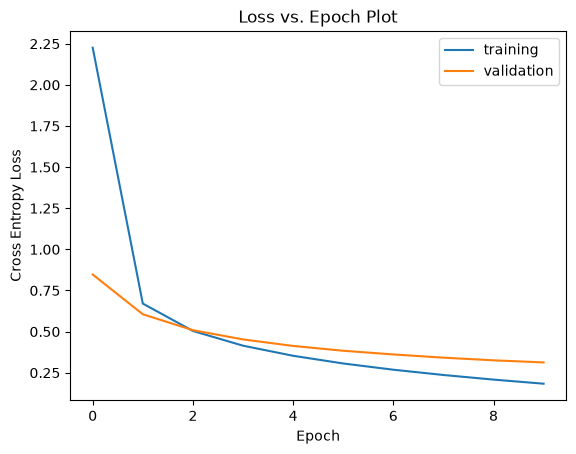

In [17]:
import matplotlib.pyplot as plt
# make plot for loss

plt.plot(train_loss, label="training")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Loss vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_loss_plot.png')
plt.show()

## Summary

The baseline model had run for 10 epochs with a final metrics of:
- Train Loss: 0.1834
- Validation Loss: 0.3127
- Test loss: 0.3052
- Training took 57m 57s


## Sample Inferences


In [185]:
# sample indices
i_1 = 100
i_2 = 200
i_3 = 300
i_4 = 400
i_5 = 500

In [186]:
sample_1 = test_ds[i_1]

In [187]:
sample_1

(tensor([   1,  505,  274, 2781,    2,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]),
 tensor([   1,   83, 1554, 1553,    8,    2,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0]))

In [188]:
eng_1, frc_1 = sample_1

In [189]:
import pandas as pd
from transformer.data.vocabulary import map_token_to_id, map_id_to_token
from transformer.model.config import ENGLISH, FRENCH
from transformer.data.tokenizer import tokenize
## create english and french vocab dictionaries
# load dataset
df = pd.read_csv(local_prefix + DATASET_FILENAME)

# seperate languages
english_df = df[ENGLISH]
french_df = df[FRENCH]

# vocabs
eng_vocab = map_token_to_id(tokenize(english_df))
inv_eng_vocab = map_id_to_token(eng_vocab)
frc_vocab = map_token_to_id(tokenize(french_df))
inv_frc_vocab = map_id_to_token(frc_vocab)

In [190]:
def do_map(token_seq, vocab):
    
    id_seq = []
    for token in token_seq:
        id_seq.append(vocab[token.item()])
    
    return id_seq

In [191]:
# get original setences
origin_eng_1 = do_map(eng_1, inv_eng_vocab)

In [192]:
# process tokeen seuence into string
def process_token_seq(token_seq):
    sentence = ""
    for token in token_seq:
        if token not in ['<SOS>', '<EOS>', '<PAD>', '<UNK>']:
            sentence += token + " "
    
    return sentence.strip()

In [193]:
print(process_token_seq(origin_eng_1))

Are we finished?


In [194]:
def print_sentences(src_token_seq, tgt_token_seq, src_vocab, tgt_vocab):
    src = do_map(src_token_seq, src_vocab)
    tgt = do_map(tgt_token_seq, tgt_vocab)

    print("\tSource:", process_token_seq(src))
    print("\tTarget:", process_token_seq(tgt))

In [195]:
print_sentences(eng_1, frc_1, inv_eng_vocab, inv_frc_vocab)

	Source: Are we finished?
	Target: En avons-nous terminé ?


In [196]:
# first inference
print(eng_1.shape)
print(frc_1.shape)
eng_1 = torch.unsqueeze(eng_1, 0)
frc_1 = torch.unsqueeze(frc_1, 0)
print(eng_1.shape)
print(frc_1.shape)
output = model(eng_1, frc_1)


torch.Size([46])
torch.Size([57])
torch.Size([1, 46])
torch.Size([1, 57])


In [197]:
values, indices = torch.max(output, 2)

In [198]:
indices = torch.squeeze(indices, 0)
indices
len(indices)

57

In [199]:
sentence = process_token_seq(do_map(indices, inv_frc_vocab))
output.shape

torch.Size([1, 57, 48673])

In [200]:
print("Translation:", sentence)

Translation: En pensais terminé ?


In [201]:
def inference(model, sample, src_vocab, tgt_vocab):

    # print sample
    src_token_seq, tgt_token_seq = sample
    print_sentences(src_token_seq, tgt_token_seq, src_vocab, tgt_vocab)

    # do inference
    src_token_seq = torch.unsqueeze(src_token_seq, 0)
    tgt_token_seq = torch.unsqueeze(tgt_token_seq, 0)
    output = model(src_token_seq, tgt_token_seq)
    _, indices = torch.max(output, 2)

    # process and print translated sentence
    indices = torch.squeeze(indices, 0)
    sentence = process_token_seq(do_map(indices, inv_frc_vocab))
    print("\tTranslation:", sentence)

## Sample Inferences

In [202]:
# sample
print(f"Sample #{i_1}:")
inference(model, test_ds[i_1], inv_eng_vocab, inv_frc_vocab)

Sample #100:
	Source: Are we finished?
	Target: En avons-nous terminé ?
	Translation: En pensais terminé ?


In [203]:
# rest of samples
for i in [i_1, i_2, i_3, i_4, i_5]:
    print(f"Sample #{i}:")
    inference(model, test_ds[i], inv_eng_vocab, inv_frc_vocab)
    print("\n---------------------------------------------------------------------------------------\n")

Sample #100:
	Source: Are we finished?
	Target: En avons-nous terminé ?
	Translation: En pensais terminé ?

---------------------------------------------------------------------------------------

Sample #200:
	Source: I just want to say I'm sorry.
	Target: Je veux juste dire que je suis désolé.
	Translation: Je veux juste dire que je suis désolé.

---------------------------------------------------------------------------------------

Sample #300:
	Source: I can't believe I let you talk me into this.
	Target: Je n'arrive pas à croire que je te laisse m'en persuader.
	Translation: Je n'arrive pas à croire que je te laisse m'en mal

---------------------------------------------------------------------------------------

Sample #400:
	Source: You're a man now.
	Target: Vous êtes désormais un homme.
	Translation: Vous êtes désormais un homme.

---------------------------------------------------------------------------------------

Sample #500:
	Source: It's a great night to go dancing.
	T

## Save Model

In [204]:
# Save the weights to a file
torch.save(model.state_dict(), './model-weights/baseline_transformer.pth')